In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
from rdkit import Chem

mol = Chem.MolFromSmiles("CCO")
print("RDKit OK:", mol is not None)

RDKit OK: True


In [3]:
from DeepPurpose import utils
from DeepPurpose import DTI as models

drug_encoding = "CNN"
target_encoding = "CNN"

config = utils.generate_config(drug_encoding, target_encoding)
model = models.model_initialize(**config)

print("DeepPurpose OK")

DeepPurpose OK


In [5]:
# Drug SMILES
drug = ["CCO"]   # ethanol example

# Protein sequence (example protein)
target = ["MKTFFVAGVILLLLAVAFSSATA"]

# ===== 3 编码方式 =====
drug_encoding = "CNN"
target_encoding = "CNN"

# ===== 4 生成配置 =====
config = utils.generate_config(
    drug_encoding = drug_encoding,
    target_encoding = target_encoding,
    train_epoch = 1,
    batch_size = 32
)

# ===== 5 初始化模型 =====
model = models.model_initialize(**config)

# ===== 6 数据预处理 =====
data = utils.data_process(
    drug,
    target,
    [0],
    drug_encoding,
    target_encoding,
    split_method='no_split'
)

# ===== 7 预测 =====
pred = model.predict(data)

print("Prediction:", pred)

Drug Target Interaction Prediction Mode...
in total: 1 drug-target pairs
encoding drug...
unique drugs: 1
encoding protein...
unique target sequence: 1
splitting dataset...
do not do train/test split on the data for already splitted data
predicting...
Prediction: [-0.01132097840309143]


CUDA: True
Drug Target Interaction Prediction Mode...
in total: 4 drug-target pairs
encoding drug...
unique drugs: 4
encoding protein...
unique target sequence: 1
splitting dataset...
do not do train/test split on the data for already splitted data
predicting...
          Drug                                  SMILES     Score
2  Chloroquine  CCN(CC)CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl  0.038131
3  ExampleDrug                   CC1=C(C(=O)NC(=O)N1)N  0.038100
0      Ethanol                                     CCO  0.038036
1      Aspirin                CC(=O)OC1=CC=CC=C1C(=O)O  0.038028


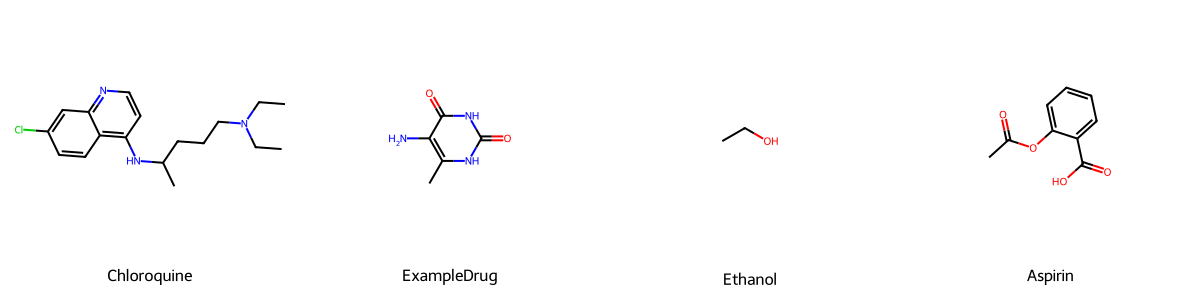

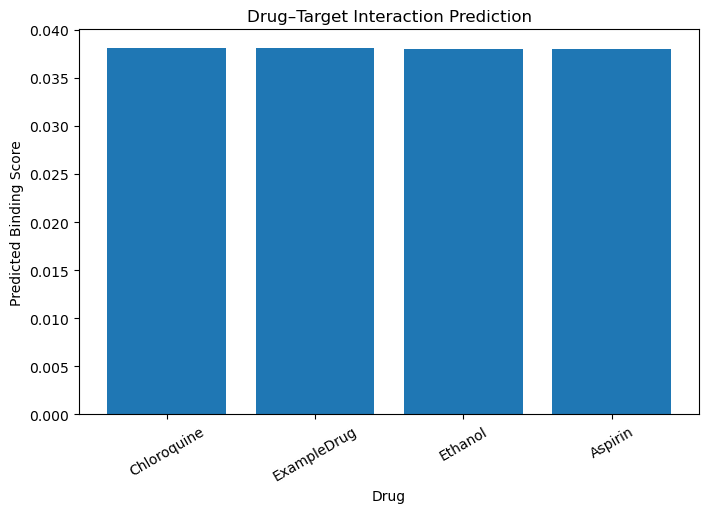

In [6]:
import torch
from DeepPurpose import utils
from DeepPurpose import DTI as models
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
import pandas as pd

print("CUDA:", torch.cuda.is_available())

# ===== 示例药物 SMILES =====
drugs = [
    "CCO",                          # ethanol
    "CC(=O)OC1=CC=CC=C1C(=O)O",     # aspirin
    "CCN(CC)CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl",  # chloroquine
    "CC1=C(C(=O)NC(=O)N1)N",        # cytosine derivative
]

drug_names = [
    "Ethanol",
    "Aspirin",
    "Chloroquine",
    "ExampleDrug"
]

# ===== 示例蛋白序列 =====
target = ["MKTFFVAGVILLLLAVAFSSATA"]

# ===== 编码方式 =====
drug_encoding = "CNN"
target_encoding = "CNN"

config = utils.generate_config(
    drug_encoding=drug_encoding,
    target_encoding=target_encoding,
    train_epoch=1,
    batch_size=32
)

# ===== 初始化模型 =====
model = models.model_initialize(**config)

# ===== 数据处理 =====
data = utils.data_process(
    drugs,
    target * len(drugs),
    [0]*len(drugs),
    drug_encoding,
    target_encoding,
    split_method='no_split'
)

# ===== 预测 =====
pred = model.predict(data)

# ===== 整理结果 =====
df = pd.DataFrame({
    "Drug": drug_names,
    "SMILES": drugs,
    "Score": pred
})

df = df.sort_values("Score", ascending=False)

print(df)

# ===== 1 画分子结构 =====
mols = [Chem.MolFromSmiles(s) for s in df["SMILES"]]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    legends=df["Drug"].tolist(),
    subImgSize=(300,300)
)

display(img)

# ===== 2 画预测分数柱状图 =====
plt.figure(figsize=(8,5))

plt.bar(df["Drug"], df["Score"])

plt.xlabel("Drug")
plt.ylabel("Predicted Binding Score")
plt.title("Drug–Target Interaction Prediction")

plt.xticks(rotation=30)

plt.show()

CUDA: True
Drug Target Interaction Prediction Mode...
in total: 8 drug-target pairs
encoding drug...
unique drugs: 8
encoding protein...
unique target sequence: 1
splitting dataset...
do not do train/test split on the data for already splitted data
predicting...
               Drug                                  SMILES     Score
0           Ethanol                                     CCO  0.026661
6  Propranolol_like                           CC(C)NCC(O)CO  0.026590
4         Ibuprofen           CC(C)CC1=CC=C(C=C1)C(C)C(=O)O  0.026587
3      Benzaldehyde                        C1=CC=C(C=C1)C=O  0.026573
2       Chloroquine  CCN(CC)CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl  0.026565
7     EthylBenzoate                     CCOC(=O)C1=CC=CC=C1  0.026526
1           Aspirin                CC(=O)OC1=CC=CC=C1C(=O)O  0.026515
5       Naphthalene                   C1=CC=C2C(=C1)C=CC=C2  0.026503


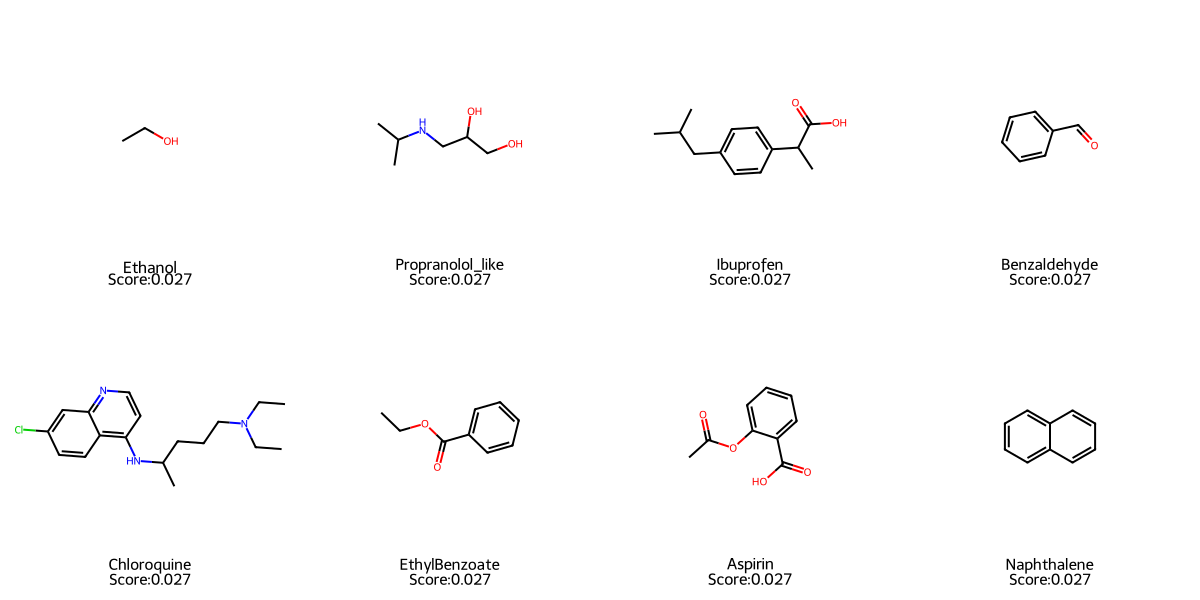

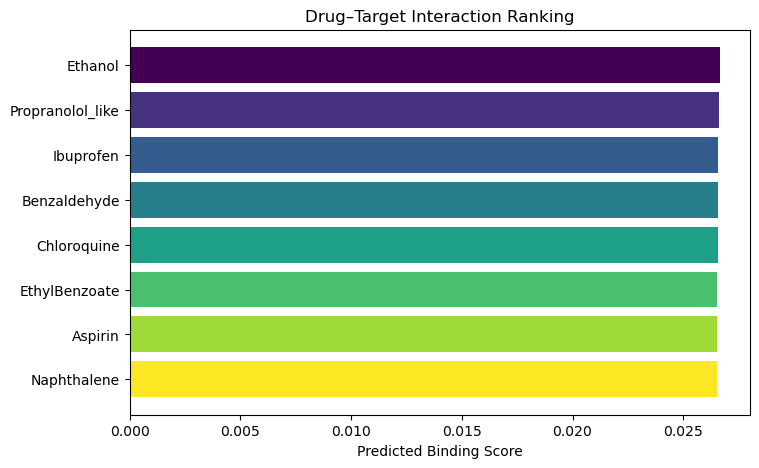

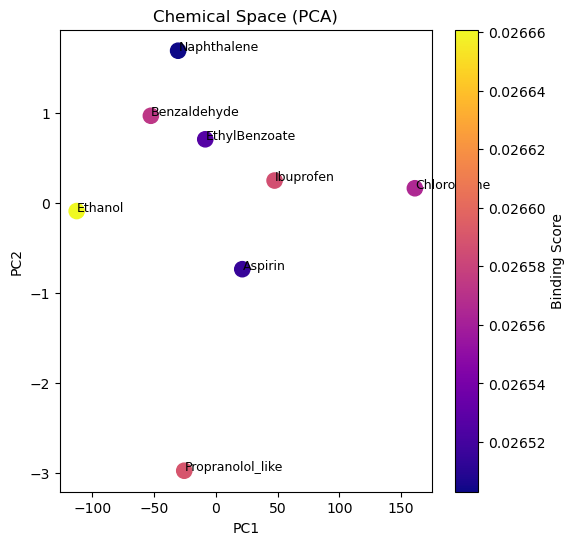

In [7]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from DeepPurpose import utils
from DeepPurpose import DTI as models

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors

from sklearn.decomposition import PCA

print("CUDA:", torch.cuda.is_available())

# ===============================
# 1 准备药物库
# ===============================

drugs = [
    "CCO",
    "CC(=O)OC1=CC=CC=C1C(=O)O",
    "CCN(CC)CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl",
    "C1=CC=C(C=C1)C=O",
    "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "C1=CC=C2C(=C1)C=CC=C2",
    "CC(C)NCC(O)CO",
    "CCOC(=O)C1=CC=CC=C1",
]

drug_names = [
    "Ethanol",
    "Aspirin",
    "Chloroquine",
    "Benzaldehyde",
    "Ibuprofen",
    "Naphthalene",
    "Propranolol_like",
    "EthylBenzoate"
]

# 示例蛋白
target = ["MKTFFVAGVILLLLAVAFSSATA"]

# ===============================
# 2 初始化模型
# ===============================

drug_encoding = "CNN"
target_encoding = "CNN"

config = utils.generate_config(
    drug_encoding=drug_encoding,
    target_encoding=target_encoding,
    train_epoch=1
)

model = models.model_initialize(**config)

# ===============================
# 3 数据处理
# ===============================

data = utils.data_process(
    drugs,
    target * len(drugs),
    [0]*len(drugs),
    drug_encoding,
    target_encoding,
    split_method='no_split'
)

# ===============================
# 4 预测
# ===============================

pred = model.predict(data)

df = pd.DataFrame({
    "Drug": drug_names,
    "SMILES": drugs,
    "Score": pred
})

df = df.sort_values("Score", ascending=False)

print(df)

# ===============================
# 5 分子结构图
# ===============================

mols = [Chem.MolFromSmiles(s) for s in df["SMILES"]]

legends = [
    f"{d}\nScore:{round(s,3)}"
    for d, s in zip(df["Drug"], df["Score"])
]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    legends=legends,
    subImgSize=(300,300)
)

display(img)

# ===============================
# 6 Binding Score 排名图
# ===============================

plt.figure(figsize=(8,5))

colors = plt.cm.viridis(np.linspace(0,1,len(df)))

plt.barh(df["Drug"], df["Score"], color=colors)

plt.xlabel("Predicted Binding Score")
plt.title("Drug–Target Interaction Ranking")

plt.gca().invert_yaxis()

plt.show()

# ===============================
# 7 化学空间 PCA 图
# ===============================

mw = [Descriptors.MolWt(Chem.MolFromSmiles(s)) for s in drugs]
logp = [Descriptors.MolLogP(Chem.MolFromSmiles(s)) for s in drugs]
hbd = [Descriptors.NumHDonors(Chem.MolFromSmiles(s)) for s in drugs]

X = np.array([mw, logp, hbd]).T

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=pred,
    cmap="plasma",
    s=120
)

for i, name in enumerate(drug_names):
    plt.text(X_pca[i,0]+0.2, X_pca[i,1], name, fontsize=9)

plt.colorbar(label="Binding Score")

plt.title("Chemical Space (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()